Using device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 484kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.08MB/s]



TASK 1: ACTIVATION FUNCTION CHALLENGE

Training CNN with sigmoid activation and Adam optimizer...
Epoch [2/10] - Train Loss: 0.5740, Train Acc: 91.14%, Test Acc: 95.92%
Epoch [4/10] - Train Loss: 0.0827, Train Acc: 97.76%, Test Acc: 98.08%
Epoch [6/10] - Train Loss: 0.0466, Train Acc: 98.71%, Test Acc: 98.37%
Epoch [8/10] - Train Loss: 0.0314, Train Acc: 99.14%, Test Acc: 98.70%
Epoch [10/10] - Train Loss: 0.0227, Train Acc: 99.38%, Test Acc: 98.91%

Training CNN with tanh activation and Adam optimizer...
Epoch [2/10] - Train Loss: 0.0597, Train Acc: 98.20%, Test Acc: 98.11%
Epoch [4/10] - Train Loss: 0.0357, Train Acc: 98.93%, Test Acc: 98.29%
Epoch [6/10] - Train Loss: 0.0281, Train Acc: 99.14%, Test Acc: 98.37%
Epoch [8/10] - Train Loss: 0.0228, Train Acc: 99.32%, Test Acc: 98.50%
Epoch [10/10] - Train Loss: 0.0217, Train Acc: 99.34%, Test Acc: 98.46%

Training CNN with relu activation and Adam optimizer...
Epoch [2/10] - Train Loss: 0.0436, Train Acc: 98.65%, Test Acc: 98.94%
Epoc

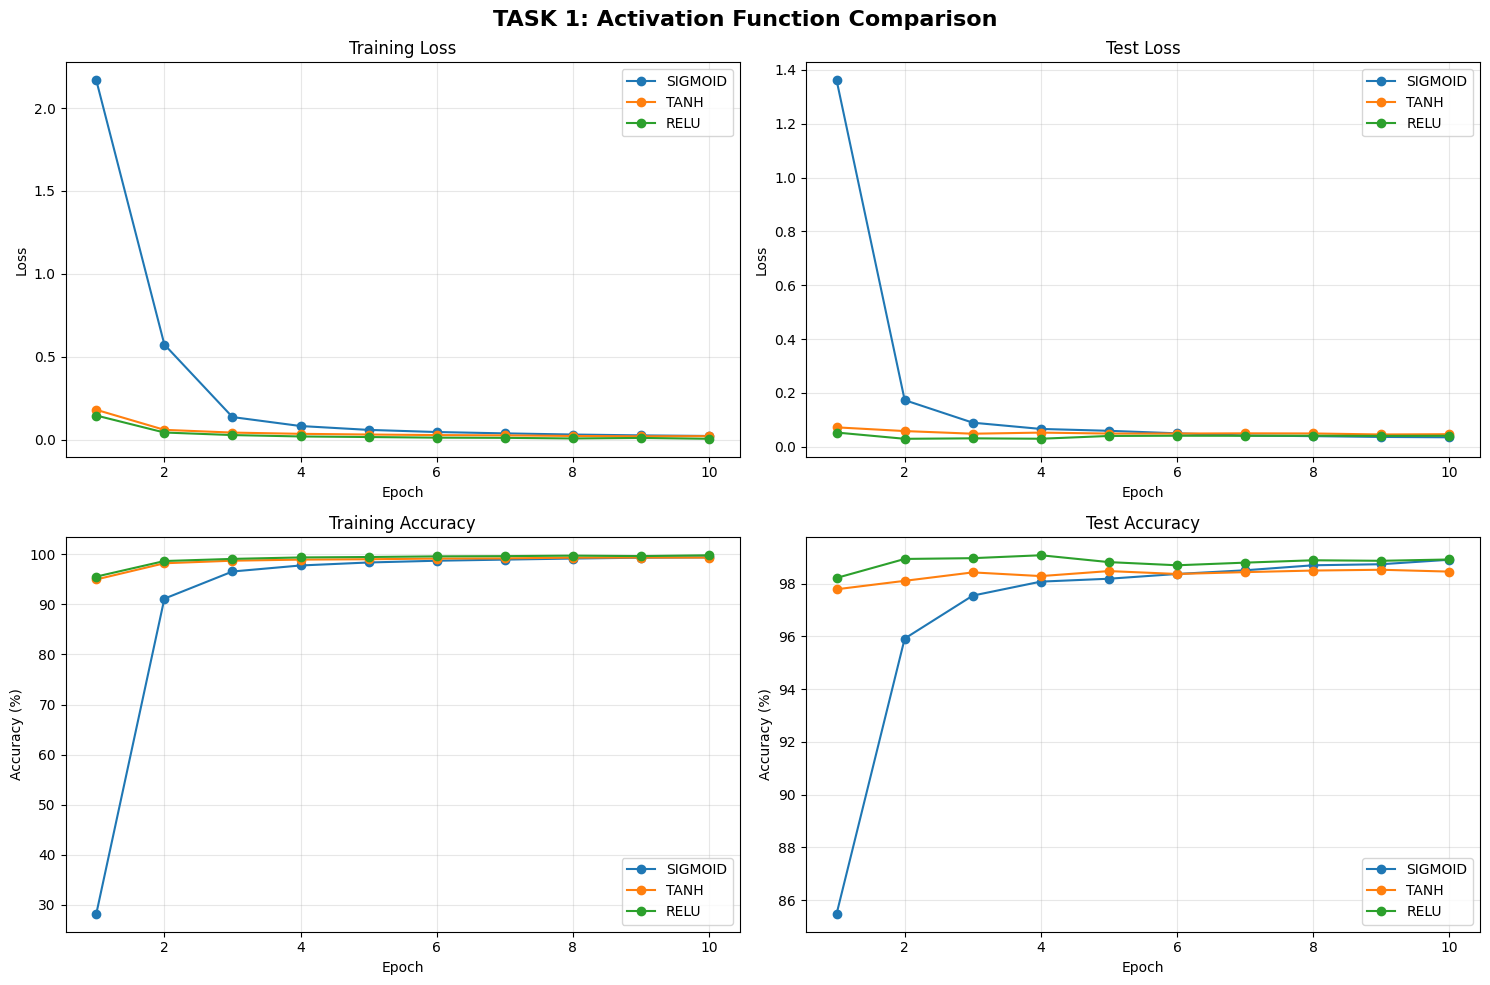

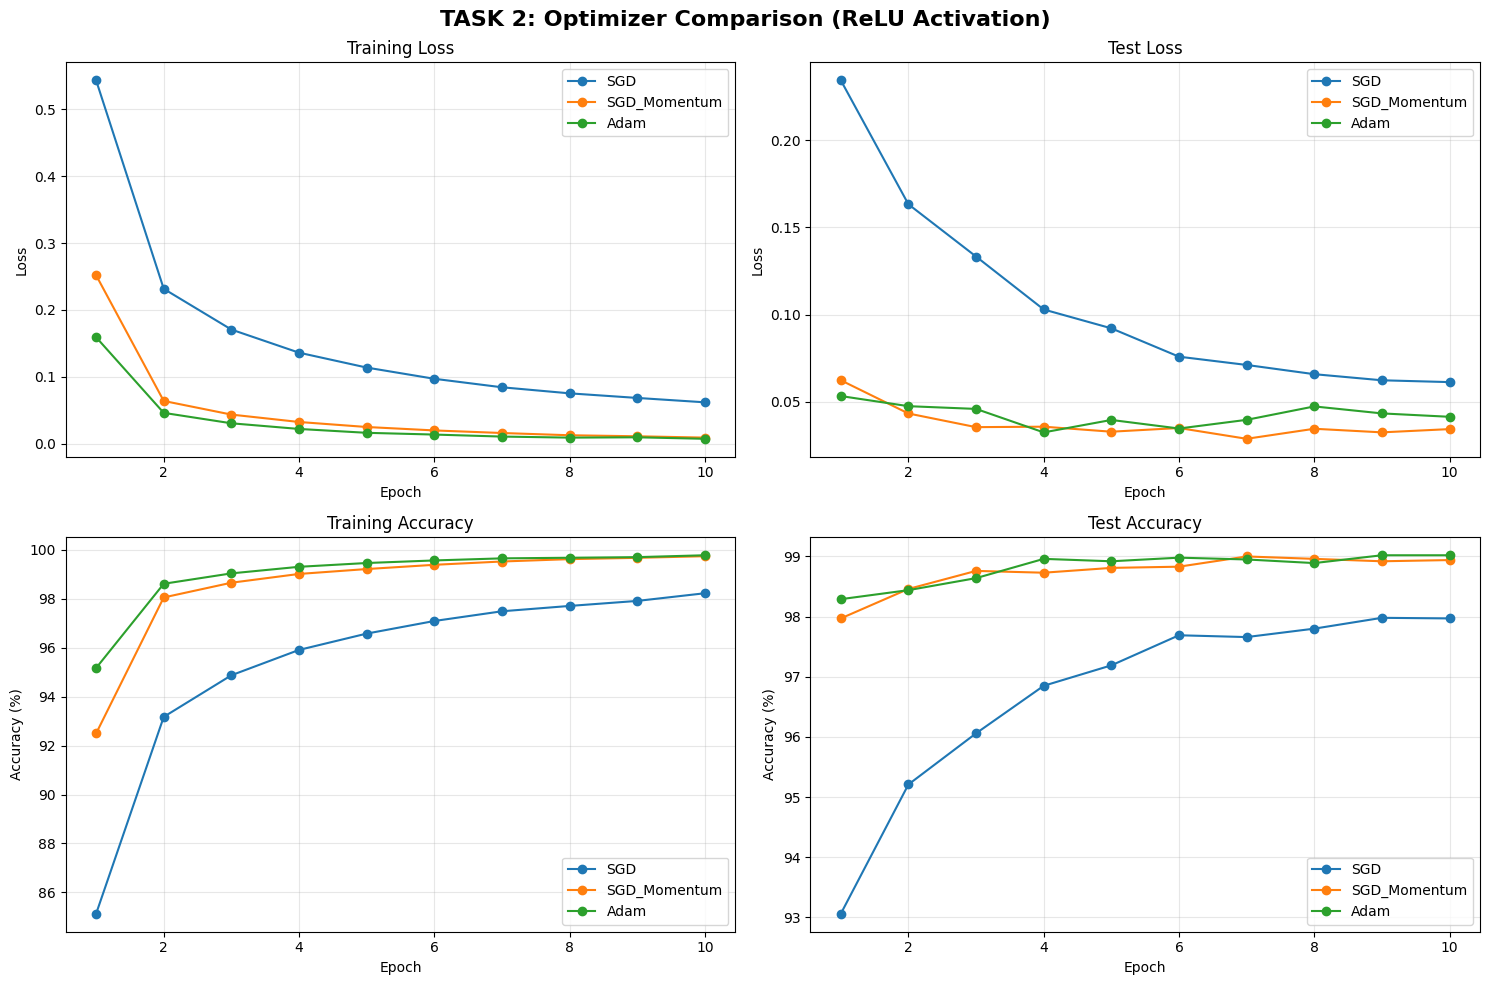

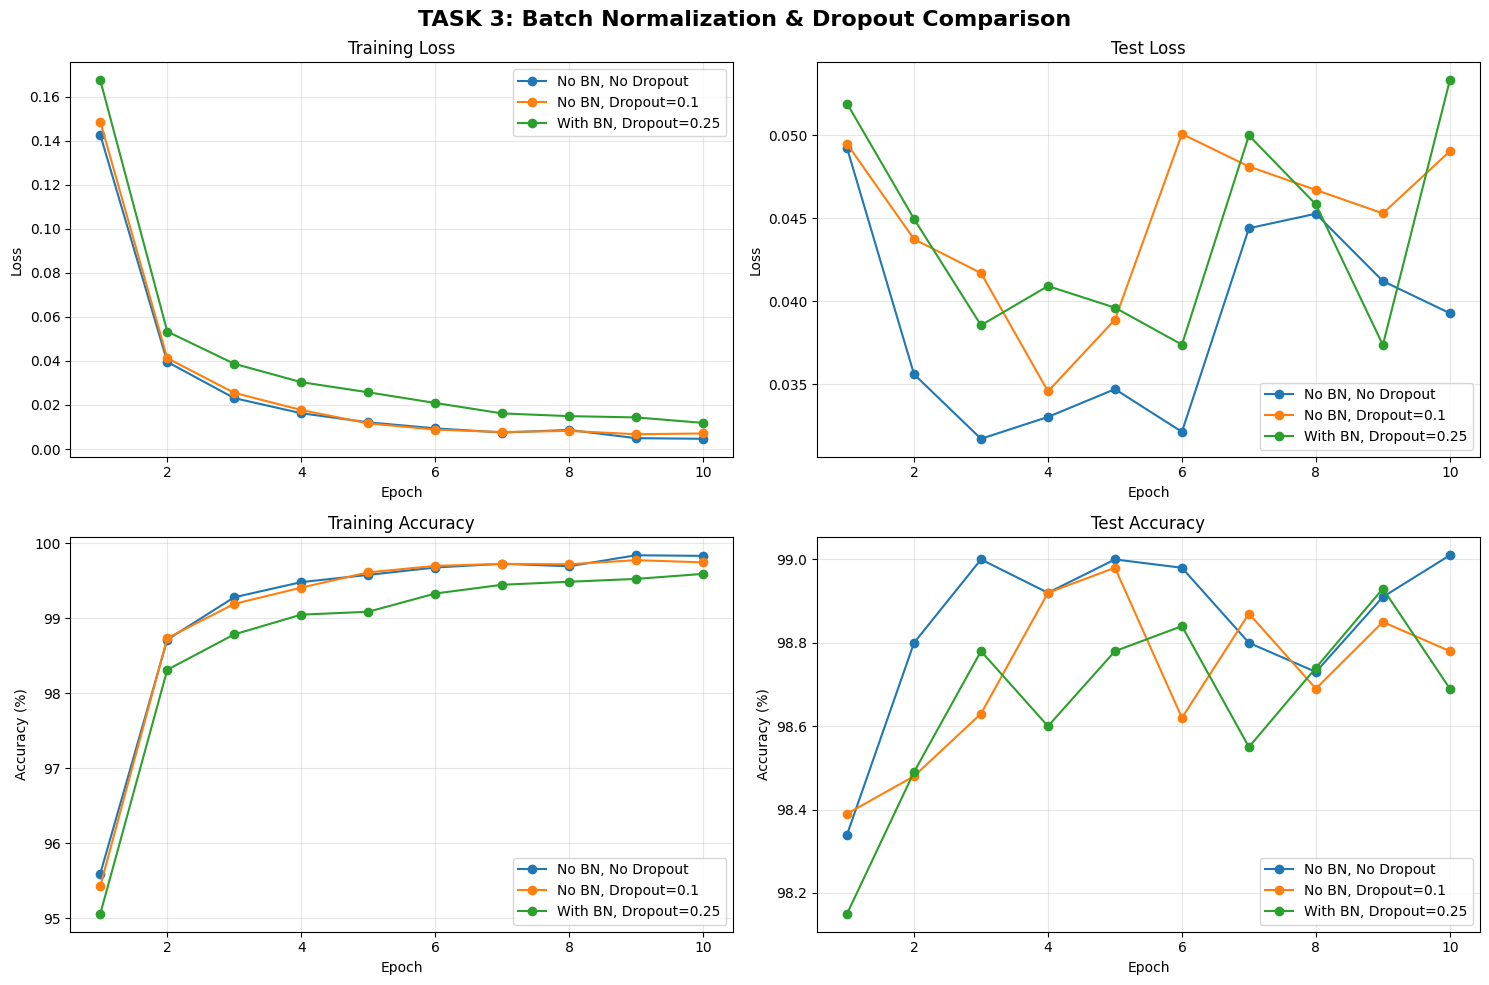

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Data preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

# ==================== CNN MODEL ====================
class CNN(nn.Module):
    def __init__(self, activation='relu', use_bn=False, dropout_rate=0.25, fc_neurons=128):
        super(CNN, self).__init__()

        # Activation function selection
        if activation == 'sigmoid':
            self.activation_fn = nn.Sigmoid
        elif activation == 'tanh':
            self.activation_fn = nn.Tanh
        else:  # relu
            self.activation_fn = nn.ReLU

        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Batch normalization (optional)
        self.use_bn = use_bn
        if use_bn:
            self.bn1 = nn.BatchNorm2d(32)
            self.bn2 = nn.BatchNorm2d(64)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

        # Fully connected layers
        # After conv1 (padding=1): 28x28 -> 28x28
        # After conv2 (padding=1): 28x28 -> 28x28
        # After pool (2x2): 28x28 -> 14x14
        # So flattened size is: 64 * 14 * 14
        self.fc1 = nn.Linear(64 * 14 * 14, fc_neurons)
        self.fc2 = nn.Linear(fc_neurons, 10)

    def forward(self, x):
        # Conv layer 1
        x = self.conv1(x)
        if self.use_bn:
            x = self.bn1(x)
        x = self.activation_fn()(x)

        # Conv layer 2
        x = self.conv2(x)
        if self.use_bn:
            x = self.bn2(x)
        x = self.activation_fn()(x)

        # Max pooling
        x = self.pool(x)

        # Dropout
        if self.dropout:
            x = self.dropout(x)

        # Flatten
        batch_size = x.size(0)
        x = x.view(batch_size, -1)

        # FC layers
        x = self.fc1(x)
        x = self.activation_fn()(x)
        x = self.fc2(x)

        return x

# ==================== MLP MODEL ====================
class MLP(nn.Module):
    def __init__(self, hidden_layers=[256, 128], activation='relu', use_bn=True, dropout_rate=0.25):
        super(MLP, self).__init__()

        # Activation function
        if activation == 'sigmoid':
            self.activation_fn = nn.Sigmoid
        elif activation == 'tanh':
            self.activation_fn = nn.Tanh
        else:
            self.activation_fn = nn.ReLU

        self.use_bn = use_bn
        self.dropout_rate = dropout_rate
        layers = []

        # Input layer
        input_size = 784
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(input_size, hidden_size))
            if use_bn:
                layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(self.activation_fn())
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
            input_size = hidden_size

        # Output layer (no activation here, CrossEntropyLoss includes softmax)
        layers.append(nn.Linear(input_size, 10))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1)  # Flatten: (batch_size, 784)
        return self.network(x)

# ==================== TRAINING FUNCTION ====================
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# ==================== TESTING FUNCTION ====================
def test_model(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(test_loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

# ==================== EXPERIMENT RUNNER ====================
def run_experiment(model_type, activation, optimizer_name, epochs,
                   use_bn=False, dropout_rate=0.25, hidden_layers=None, fc_neurons=128):

    # Create model
    if model_type == 'CNN':
        model = CNN(activation=activation, use_bn=use_bn,
                   dropout_rate=dropout_rate, fc_neurons=fc_neurons).to(device)
    else:  # MLP
        if hidden_layers is None:
            hidden_layers = [256, 128]
        model = MLP(hidden_layers=hidden_layers, activation=activation,
                   use_bn=use_bn, dropout_rate=dropout_rate).to(device)

    # Loss function
    criterion = nn.CrossEntropyLoss()

    # Optimizer
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.01)
    elif optimizer_name == 'SGD_Momentum':
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    else:  # Adam
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Training history
    train_losses, train_accs = [], []
    test_losses, test_accs = [], []

    print(f"\nTraining {model_type} with {activation} activation and {optimizer_name} optimizer...")

    for epoch in range(epochs):
        train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = test_model(model, test_loader, criterion, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

        if (epoch + 1) % 2 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] - Train Loss: {train_loss:.4f}, '
                  f'Train Acc: {train_acc:.2f}%, Test Acc: {test_acc:.2f}%')

    return {
        'train_losses': train_losses,
        'train_accs': train_accs,
        'test_losses': test_losses,
        'test_accs': test_accs,
        'final_test_acc': test_accs[-1]
    }

# ==================== TASK 1: ACTIVATION FUNCTION CHALLENGE ====================
print("\n" + "="*60)
print("TASK 1: ACTIVATION FUNCTION CHALLENGE")
print("="*60)

task1_results = []
task1_histories = {}

activations = ['sigmoid', 'tanh', 'relu']
for activation in activations:
    history = run_experiment('CNN', activation, 'Adam', epochs=10, fc_neurons=128)
    task1_results.append({
        'Experiment': f'CNN-{activation}',
        'Activation': activation,
        'Optimizer': 'Adam',
        'Epochs': 10,
        'Final Test Accuracy': f"{history['final_test_acc']:.2f}%"
    })
    task1_histories[activation] = history

# Display results
print("\n" + "-"*60)
print("TASK 1 RESULTS:")
df_task1 = pd.DataFrame(task1_results)
print(df_task1.to_string(index=False))

# ==================== TASK 2: OPTIMIZER SHOWDOWN ====================
print("\n" + "="*60)
print("TASK 2: OPTIMIZER SHOWDOWN (Using ReLU)")
print("="*60)

task2_results = []
task2_histories = {}

optimizers = ['SGD', 'SGD_Momentum', 'Adam']
for opt in optimizers:
    history = run_experiment('CNN', 'relu', opt, epochs=10, fc_neurons=128)
    task2_results.append({
        'Experiment': f'CNN-{opt}',
        'Activation': 'relu',
        'Optimizer': opt,
        'Epochs': 10,
        'Final Test Accuracy': f"{history['final_test_acc']:.2f}%"
    })
    task2_histories[opt] = history

# Display results
print("\n" + "-"*60)
print("TASK 2 RESULTS:")
df_task2 = pd.DataFrame(task2_results)
print(df_task2.to_string(index=False))

# ==================== TASK 3: BATCH NORMALIZATION & DROPOUT ====================
print("\n" + "="*60)
print("TASK 3: BATCH NORMALIZATION & DROPOUT COMPARISON")
print("="*60)

task3_results = []
task3_histories = {}

configs = [
    ('No BN, No Dropout', False, 0.0),
    ('No BN, Dropout=0.1', False, 0.1),
    ('With BN, Dropout=0.25', True, 0.25)
]

for name, use_bn, dropout in configs:
    history = run_experiment('CNN', 'relu', 'Adam', epochs=10,
                           use_bn=use_bn, dropout_rate=dropout, fc_neurons=128)
    task3_results.append({
        'Experiment': name,
        'Batch Norm': use_bn,
        'Dropout': dropout,
        'Final Test Accuracy': f"{history['final_test_acc']:.2f}%"
    })
    task3_histories[name] = history

# Display results
print("\n" + "-"*60)
print("TASK 3 RESULTS:")
df_task3 = pd.DataFrame(task3_results)
print(df_task3.to_string(index=False))

# ==================== REQUIRED MODEL CONFIGURATIONS ====================
print("\n" + "="*60)
print("REQUIRED MODEL CONFIGURATIONS")
print("="*60)

required_configs = []

# CNN-1: 128 FC neurons, Adam, 10 epochs
print("\nRunning CNN-1...")
hist_cnn1 = run_experiment('CNN', 'relu', 'Adam', epochs=10, fc_neurons=128)
required_configs.append({
    'Model': 'CNN-1',
    'FC Layers': '128',
    'Optimizer': 'Adam',
    'Epochs': 10,
    'Final Test Accuracy': f"{hist_cnn1['final_test_acc']:.2f}%"
})

# MLP-1: 512-256-128, SGD, 20 epochs
print("\nRunning MLP-1...")
hist_mlp1 = run_experiment('MLP', 'relu', 'SGD', epochs=20, hidden_layers=[512, 256, 128])
required_configs.append({
    'Model': 'MLP-1',
    'FC Layers': '512-256-128',
    'Optimizer': 'SGD',
    'Epochs': 20,
    'Final Test Accuracy': f"{hist_mlp1['final_test_acc']:.2f}%"
})

# MLP-2: 256, Adam, 15 epochs
print("\nRunning MLP-2...")
hist_mlp2 = run_experiment('MLP', 'relu', 'Adam', epochs=15, hidden_layers=[256])
required_configs.append({
    'Model': 'MLP-2',
    'FC Layers': '256',
    'Optimizer': 'Adam',
    'Epochs': 15,
    'Final Test Accuracy': f"{hist_mlp2['final_test_acc']:.2f}%"
})

print("\n" + "-"*60)
print("REQUIRED CONFIGURATIONS RESULTS:")
df_required = pd.DataFrame(required_configs)
print(df_required.to_string(index=False))

# ==================== VISUALIZATION ====================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS...")
print("="*60)

# Plot 1: Task 1 - Activation Functions Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('TASK 1: Activation Function Comparison', fontsize=16, fontweight='bold')

for activation in activations:
    hist = task1_histories[activation]
    epochs_range = range(1, len(hist['train_losses']) + 1)

    # Training Loss
    axes[0, 0].plot(epochs_range, hist['train_losses'], label=f'{activation.upper()}', marker='o')
    # Test Loss
    axes[0, 1].plot(epochs_range, hist['test_losses'], label=f'{activation.upper()}', marker='o')
    # Training Accuracy
    axes[1, 0].plot(epochs_range, hist['train_accs'], label=f'{activation.upper()}', marker='o')
    # Test Accuracy
    axes[1, 1].plot(epochs_range, hist['test_accs'], label=f'{activation.upper()}', marker='o')

axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Test Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Training Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Test Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task1_activation_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: task1_activation_comparison.png")

# Plot 2: Task 2 - Optimizer Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('TASK 2: Optimizer Comparison (ReLU Activation)', fontsize=16, fontweight='bold')

for opt in optimizers:
    hist = task2_histories[opt]
    epochs_range = range(1, len(hist['train_losses']) + 1)

    axes[0, 0].plot(epochs_range, hist['train_losses'], label=opt, marker='o')
    axes[0, 1].plot(epochs_range, hist['test_losses'], label=opt, marker='o')
    axes[1, 0].plot(epochs_range, hist['train_accs'], label=opt, marker='o')
    axes[1, 1].plot(epochs_range, hist['test_accs'], label=opt, marker='o')

axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Test Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Training Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Test Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task2_optimizer_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: task2_optimizer_comparison.png")

# Plot 3: Task 3 - BatchNorm & Dropout Comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('TASK 3: Batch Normalization & Dropout Comparison', fontsize=16, fontweight='bold')

for name in task3_histories.keys():
    hist = task3_histories[name]
    epochs_range = range(1, len(hist['train_losses']) + 1)

    axes[0, 0].plot(epochs_range, hist['train_losses'], label=name, marker='o')
    axes[0, 1].plot(epochs_range, hist['test_losses'], label=name, marker='o')
    axes[1, 0].plot(epochs_range, hist['train_accs'], label=name, marker='o')
    axes[1, 1].plot(epochs_range, hist['test_accs'], label=name, marker='o')

axes[0, 0].set_title('Training Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].set_title('Test Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].set_title('Training Accuracy')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].set_title('Test Accuracy')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task3_batchnorm_dropout_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: task3_batchnorm_dropout_comparison.png")

# ==================== FINAL SUMMARY ====================
print("\n" + "="*60)
print("FINAL SUMMARY - ALL EXPERIMENTS")
print("="*60)

all_results = task1_results + task2_results + task3_results + required_configs
df_all = pd.DataFrame(all_results)
print(df_all.to_string(index=False))

print("\n" + "="*60)
print("OBSERVATIONS & CONCLUSIONS")
print("="*60)
print("""
TASK 1 - Activation Functions:
• Sigmoid: Suffers from vanishing gradients, slower convergence
• Tanh: Better than Sigmoid, zero-centered, but still slower than ReLU
• ReLU: Fastest convergence, no vanishing gradient problem for positive values

TASK 2 - Optimizers:
• SGD: Stable but slow convergence, may get stuck in local minima
• SGD with Momentum: Better than SGD, handles bumps in loss landscape
• Adam: Fastest convergence, adaptive learning rates, best performance

TASK 3 - Regularization:
• Without BN & Dropout: May overfit, less generalization
• With Dropout (0.1): Some regularization, reduced overfitting
• With BN & Dropout (0.25): Best generalization, stable training

All plots have been saved to your working directory!
""")